In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fname = Path("footstep_log.txt")

base = [
    "tick", "walking_tick",
    "ref_zmp_x", "ref_zmp_y", "ref_zmp_z",
    "target_com_stance_x", "target_com_stance_y", "target_com_stance_z",
    "com_stance_x", "com_stance_y", "com_stance_z",
    "com_global_x", "com_global_y", "com_global_z",
    "lfoot_x", "lfoot_y", "lfoot_z",
    "rfoot_x", "rfoot_y", "rfoot_z",
    "target_com_global_x", "target_com_global_y", "target_com_global_z",
]
qdes = [f"q_leg_desired_{i}" for i in range(12)]
qmeas = [f"q_leg_meas_{i}" for i in range(12)]
world = [
    "phase_indicator",
    "swing_target_x", "swing_target_y", "swing_target_z",
    "ref_vrp_world_x", "ref_vrp_world_y", "ref_vrp_world_z",
    "target_com_world_x", "target_com_world_y", "target_com_world_z",
    "com_world_x", "com_world_y", "com_world_z",
    "stance_foot_x", "stance_foot_y", "stance_foot_z",
    "swing_foot_x", "swing_foot_y", "swing_foot_z",
]
cols = base + qdes + qmeas + world
n_cols = len(cols)  # 66

T = pd.read_csv(
    fname,
    sep="\t",
    skiprows=1,
    header=None,
    names=cols,
    usecols=range(n_cols),
    engine="python",
)
if T.iloc[-1].isna().any():
    T = T.iloc[:-1]

tick = T["tick"].to_numpy()
swing_tgt = T.filter(regex=r"^swing_target_").to_numpy()
vrp = T.filter(regex=r"^ref_vrp_world_").to_numpy()
com_des = T.filter(regex=r"^target_com_world_").to_numpy()
com_cur = T.filter(regex=r"^com_world_").to_numpy()
stance_f = T.filter(regex=r"^stance_foot_").to_numpy()
swing_f = T.filter(regex=r"^swing_foot_").to_numpy()

# Leg IK target (q_leg_desired) vs measured joint pos (q_leg_meas), SDK 0..11
# 0..5 left: hip_pitch, hip_roll, hip_yaw, knee, ankle_pitch, ankle_roll
# 6..11 right: same order
LEG_NAMES = [
    "L_hip_pitch", "L_hip_roll", "L_hip_yaw", "L_knee", "L_ankle_pitch", "L_ankle_roll",
    "R_hip_pitch", "R_hip_roll", "R_hip_yaw", "R_knee", "R_ankle_pitch", "R_ankle_roll",
]
q_ik = T.filter(regex=r"^q_leg_desired_").to_numpy()
q_meas = T.filter(regex=r"^q_leg_meas_").to_numpy()

print(f"rows={len(T)}, cols={T.shape[1]}")
print(f"CoM z drop: ref={com_des[:,2].min()-com_des[0,2]:+.3f} m, "
      f"meas={com_cur[:,2].min()-com_cur[0,2]:+.3f} m")
print(f"IK vs meas |err| mean={np.abs(q_meas - q_ik).mean():.4f} rad, "
      f"max={np.abs(q_meas - q_ik).max():.4f} rad")
T[["tick", "walking_tick", "phase_indicator",
   "swing_target_x", "swing_target_y", "swing_target_z",
   "ref_vrp_world_x", "target_com_world_x", "com_world_x"]].head()

rows=447, cols=66
CoM z drop: ref=-0.010 m, meas=-0.008 m
IK vs meas |err| mean=0.1299 rad, max=1.0420 rad


,tick,walking_tick,phase_indicator,swing_target_x,swing_target_y,swing_target_z,ref_vrp_world_x,target_com_world_x,com_world_x
0,0,1,0,0.087400,-0.118500,0.033978,-0.012561,0.073987,0.074954
1,1,2,0,0.088270,-0.118131,0.033978,-0.008181,0.069122,0.081998
2,2,3,0,0.085172,-0.119428,0.033978,-0.003876,0.059527,0.074799
3,3,4,0,0.083133,-0.120255,0.033978,0.001796,0.050219,0.076446
4,4,5,0,0.083837,-0.119972,0.033978,0.008233,0.043010,0.075976


n_runs=1, n_min=447, files=['footstep_log.txt']


/tmp/ipykernel_2363941/3671134986.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(0, 41))


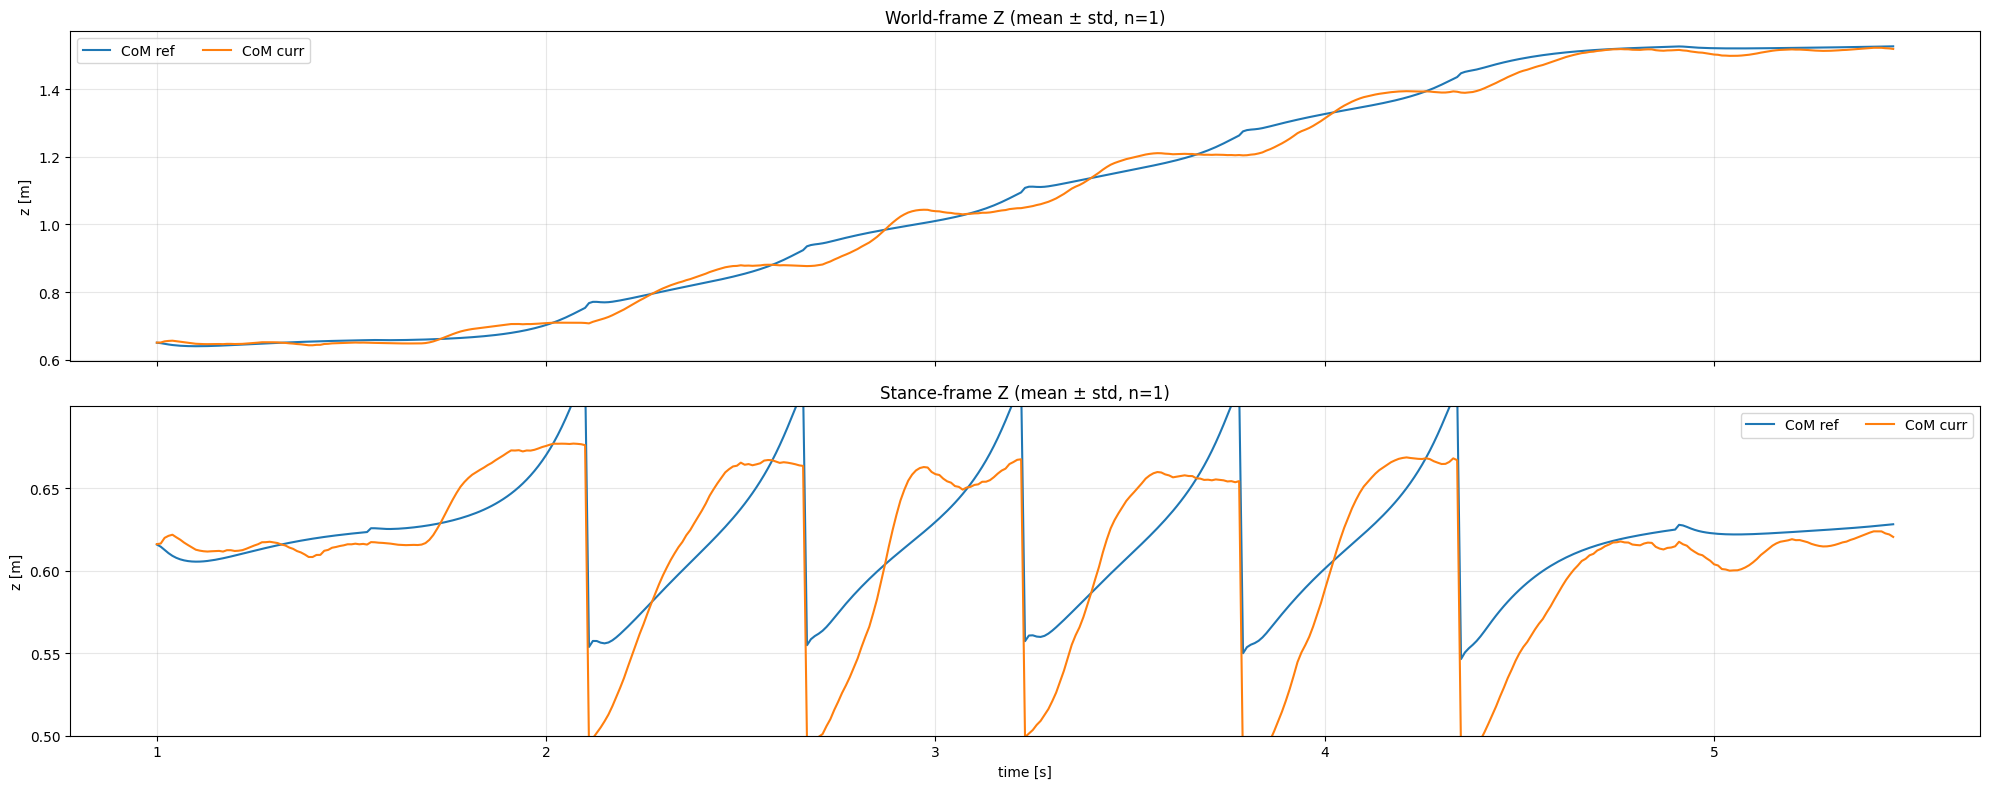

In [5]:
def load_log(path):
    df = pd.read_csv(
        path, sep="\t", skiprows=1, header=None,
        names=cols, usecols=range(n_cols), engine="python",
    )
    if df.iloc[-1].isna().any():
        df = df.iloc[:-1]
    return df

fnames = sorted(Path(".").glob("footstep_log.txt"))
runs = [load_log(p) for p in fnames]
n_min = min(len(df) for df in runs)
tick_m = runs[0]["tick"].to_numpy()[:n_min]
print(f"n_runs={len(runs)}, n_min={n_min}, files={[p.name for p in fnames]}")

def stack_col(name):
    return np.stack([df[name].to_numpy()[:n_min] for df in runs], axis=0)

def plot_mean_std(ax, t, arr, color, label):
    mu = arr.mean(axis=0)
    sd = arr.std(axis=0)
    ax.plot(t, mu, "-", lw=1.5, color=color, label=label)
    ax.fill_between(t, mu - sd, mu + sd, color=color, alpha=0.25, linewidth=0)

world_ref = stack_col("target_com_world_z")
world_cur = stack_col("com_world_z")
st_ref = stack_col("target_com_stance_z")
st_cur = stack_col("com_stance_z")

fig, axes = plt.subplots(2, 1, figsize=(20, 8), sharex=True)

ax = axes[0]
plot_mean_std(ax, tick_m, world_ref, "C0", "CoM ref")
plot_mean_std(ax, tick_m, world_cur, "C1", "CoM curr")
ax.set_ylabel("z [m]")
ax.set_title(f"World-frame Z (mean ± std, n={len(runs)})")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", ncol=3)

ax = axes[1]

# fig, ax = plt.subplots(figsize=(20, 5))
plot_mean_std(ax, tick_m, st_ref, "C0", "CoM ref")
plot_mean_std(ax, tick_m, st_cur, "C1", "CoM curr")
ax.set_xlabel("time [s]")
# ax.set_xlim(0, 2001)
# ax.set_xticks(np.arange(0, 2001, 50))
ax.set_xticklabels(np.arange(0, 41))
ax.set_ylabel("z [m]")
ax.set_ylim(0.5, 0.7)
ax.set_yticks(np.arange(0.5, 0.7, 0.05))
ax.set_title(f"Stance-frame Z (mean ± std, n={len(runs)})")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", ncol=3)

fig.tight_layout()
plt.show()

init vrp, com_des, com_cur 0.616636 0.615927 0.616168


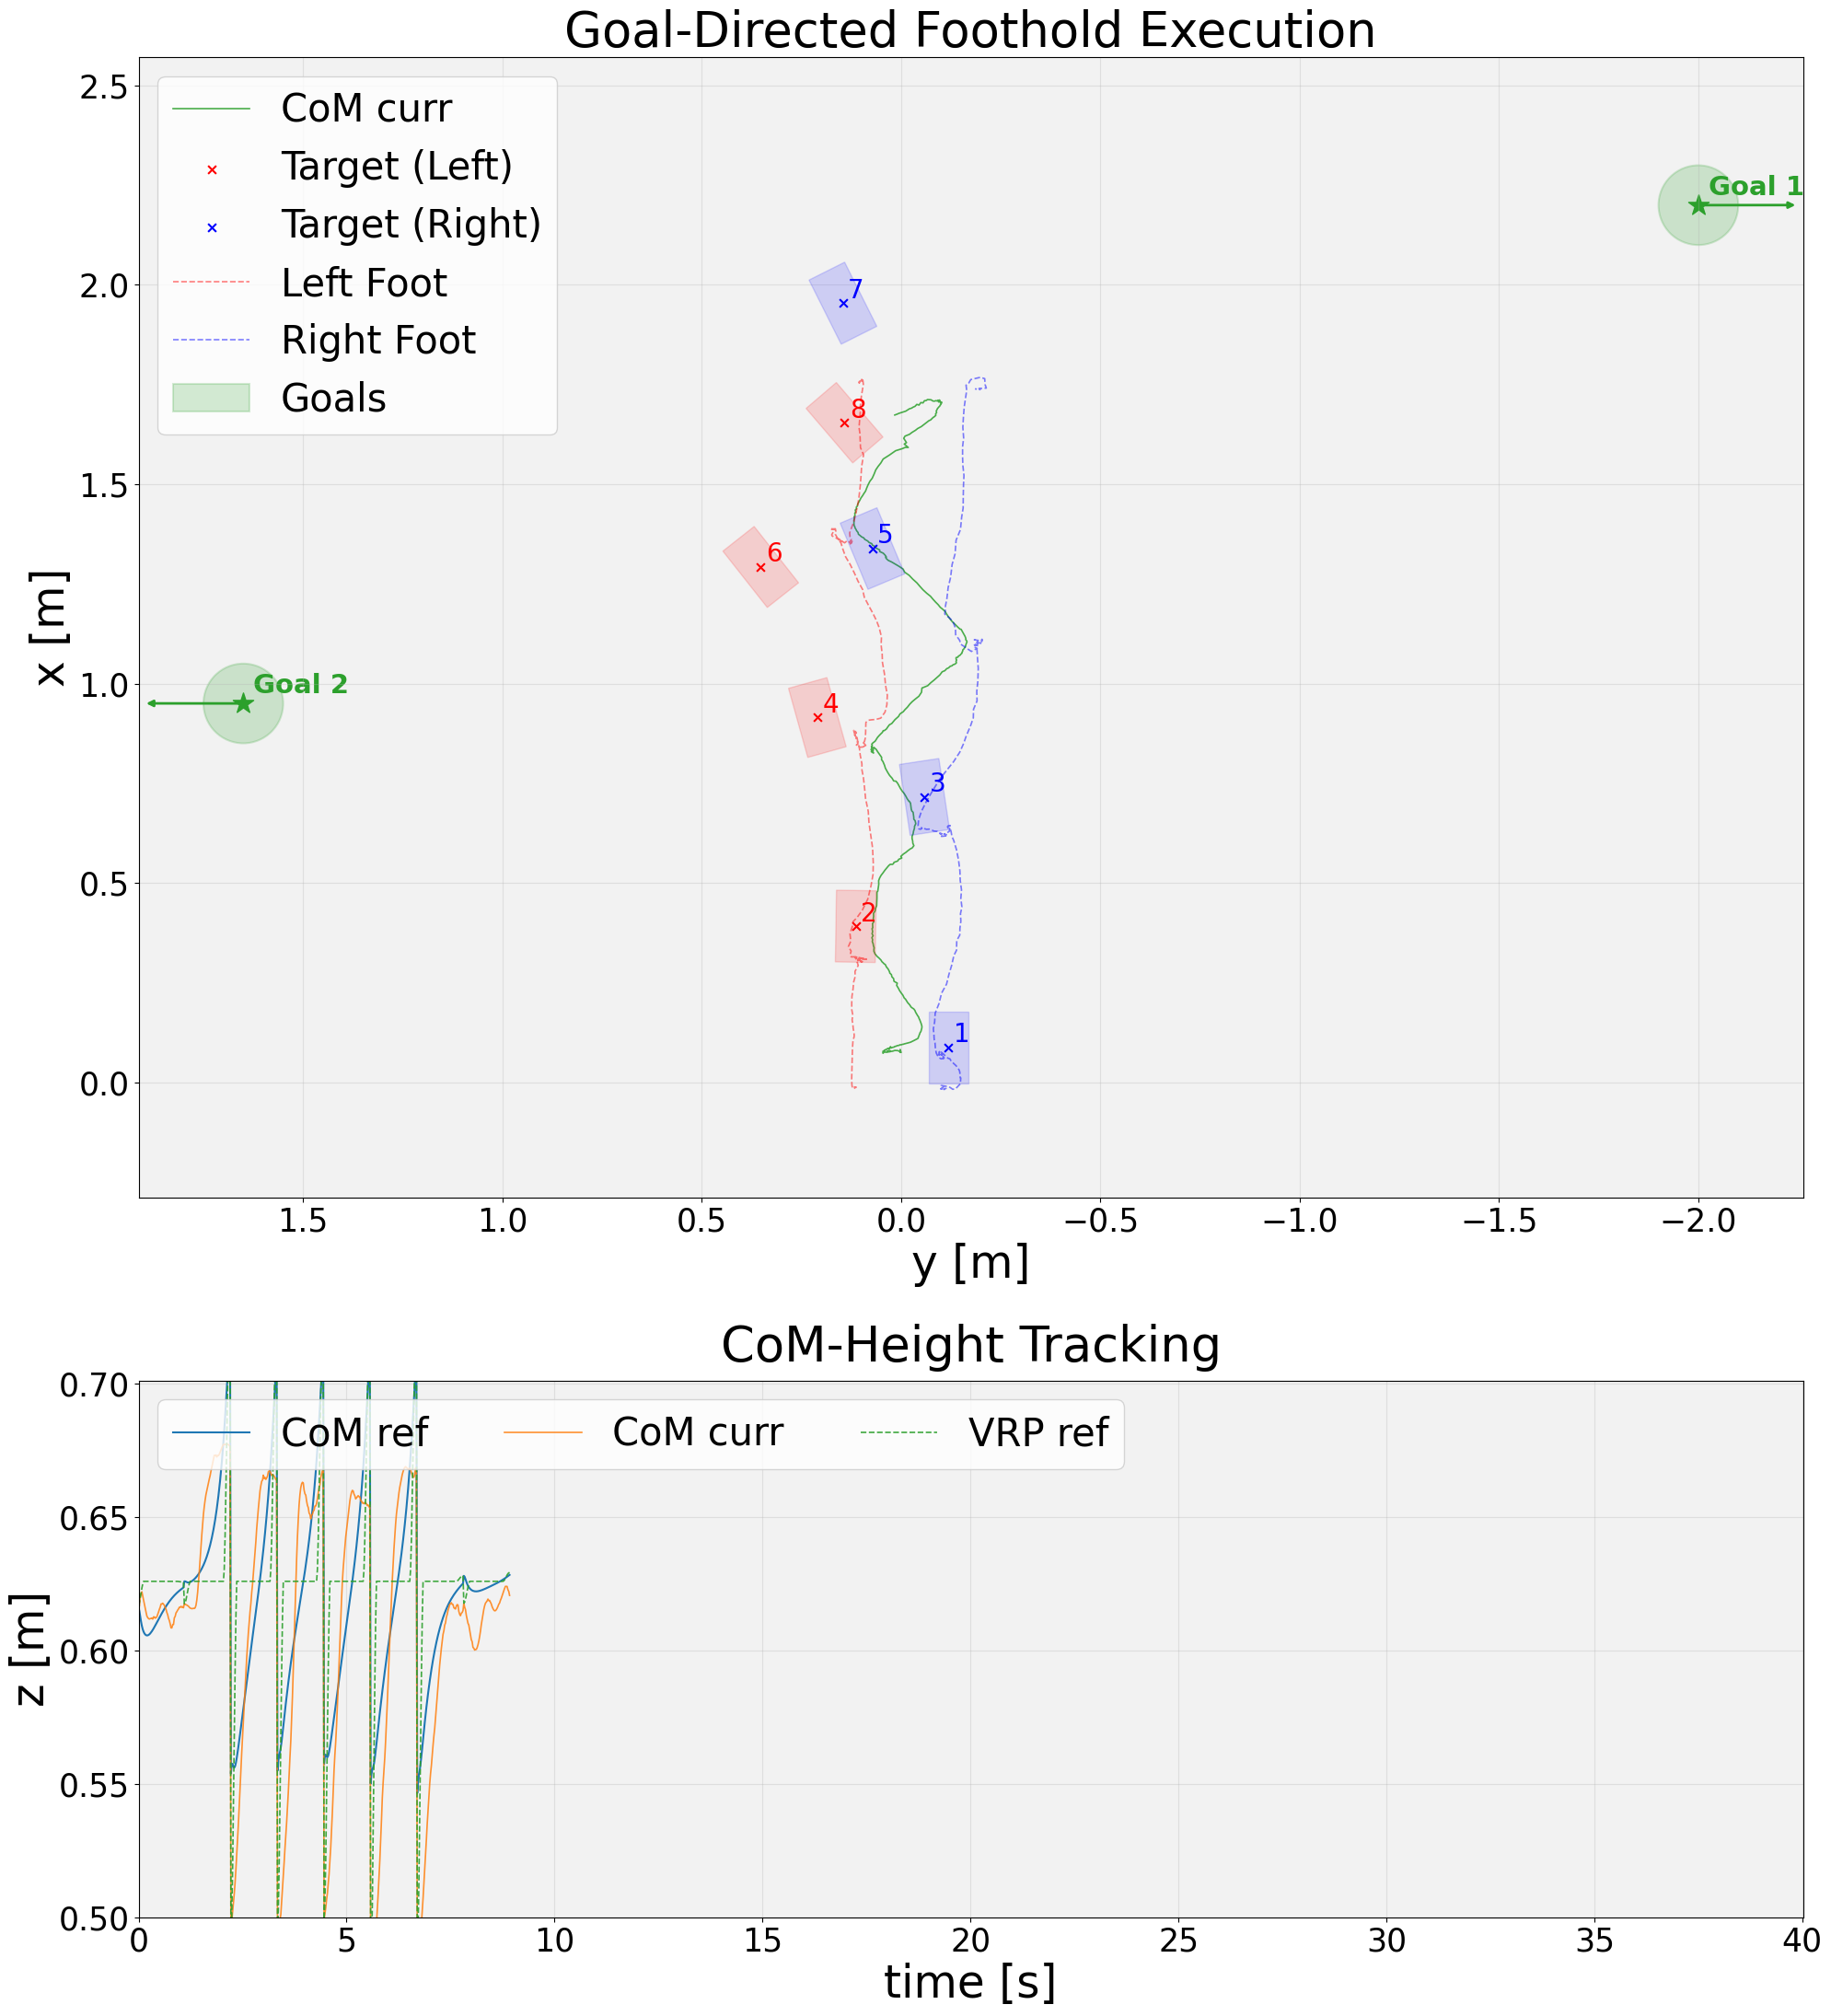


=== mean CoM z vs VRP ref until goal reach (5-trial mean, n=0) ===
  goal not reached
  goal not reached

=== 5-trial mean of (mean com_z - vrp_z until reach)  n=0 ===
  Goal 1: no trial reached
  Goal 2: no trial reached


In [12]:
com_des_st_1 = T["target_com_stance_z"].to_numpy()
com_cur_st_1 = T["com_stance_z"].to_numpy()
vrp_des_st_1 = T["ref_zmp_z"].to_numpy()

title_fs = 38
label_fs = 35
tick_fs = 25
legend_fs = 30
annot_fs = 20
FOOT_L, FOOT_W = 0.18, 0.1  # commanded foot rectangle [m]
subplot_hs = 0.218  # space between XY and Z subplots
plot_bg = "#f2f2f2"  # very light gray plot background

from matplotlib.patches import Circle, Polygon
import yaml

def foot_plot_xy(cx, cy, yaw, length=FOOT_L, width=FOOT_W):
    hx, hy = length / 2, width / 2
    local = np.array([[hx, hy], [hx, -hy], [-hx, -hy], [-hx, hy]])
    c, s = np.cos(yaw), np.sin(yaw)
    world = local @ np.array([[c, -s], [s, c]]).T + np.array([cx, cy])
    return np.column_stack([world[:, 1], world[:, 0]])  # plot (y, x)

eval_path = Path(fname.name.replace("footstep_log", "footstep_eval_260909_192129").replace(".txt", ".csv"))
E = pd.read_csv(eval_path)

goal_yaml = Path("../../config/policy/footstep/deploy_base.yaml")
_goal = yaml.safe_load(goal_yaml.read_text())["footstep"]["goal"]
goal_pts = _goal["points"]
reach_r = float(_goal.get("reach_radius", 0.1))

fig, (ax_xy, ax_z) = plt.subplots(2, 1, figsize=(20, 22), height_ratios=[6.8, 3.2])

ax_z.plot(tick, com_des_st_1, "-", lw=1.5, color="C0", label="CoM ref")
ax_z.plot(tick, com_cur_st_1, "-", lw=1.2, color="C1", label="CoM curr", alpha=0.85)
ax_z.plot(tick, vrp_des_st_1, "--", lw=1.2, color="C2", label="VRP ref", alpha=0.9)
print("init vrp, com_des, com_cur", vrp_des_st_1[0], com_des_st_1[0], com_cur_st_1[0])
ax_z.set_xlabel("time [s]", fontsize=label_fs)
ax_z.set_xlim(0, 2001)
ax_z.set_xticks(np.arange(0, 2001, 250))
ax_z.set_xticklabels(np.arange(0, 41, 5), fontsize=tick_fs)
ax_z.set_ylabel("z [m]", fontsize=label_fs)
ax_z.set_ylim(0.5, 0.701)
ax_z.set_yticks(np.arange(0.5, 0.701, 0.05))
ax_z.tick_params(axis="y", labelsize=tick_fs)
# ax_z.set_title(f"Stance-frame Z ({fname.name})", fontsize=title_fs)
ax_z.set_title(f"CoM-Height Tracking", fontsize=title_fs, pad=15)
ax_z.grid(True, alpha=0.3)
ax_z.set_facecolor(plot_bg)
ax_z.legend(loc="upper left", ncol=3, fontsize=legend_fs)

wt = T["walking_tick"].to_numpy()
step_idx = np.concatenate([[0], np.where(np.diff(wt) < 0)[0] + 1])
stance_f_xy = T.filter(regex=r"^stance_foot_").to_numpy()
n_step = min(len(E), len(step_idx))
cmd_xy = np.zeros((n_step, 2))
cmd_yaw_w = np.zeros(n_step)
stance_yaw = 0.0
for k in range(n_step):
    px, py = stance_f_xy[step_idx[k], 0], stance_f_xy[step_idx[k], 1]
    c, s = np.cos(stance_yaw), np.sin(stance_yaw)
    cx, cy = float(E["cmd_x"].iloc[k]), float(E["cmd_y"].iloc[k])
    cmd_xy[k, 0] = px + c * cx - s * cy
    cmd_xy[k, 1] = py + s * cx + c * cy
    cmd_yaw_w[k] = stance_yaw + float(E["cmd_yaw"].iloc[k])
    stance_yaw += float(E["meas_yaw"].iloc[k])
eval_foot = E["foot"].iloc[:n_step].to_numpy()
left_e = eval_foot == "L"
right_e = eval_foot == "R"
# ax_xy.plot(com_des[:, 1], com_des[:, 0], "-", lw=1.5, color="C0", label="CoM ref", alpha=0.5)
ax_xy.plot(com_cur[:, 1], com_cur[:, 0], "-", lw=1.2, label="CoM curr", color="C2", alpha=0.85)
# ax_xy.plot(vrp[:, 1], vrp[:, 0], "--", lw=1.2, color="C2", label="VRP ref", alpha=0.9)
ax_xy.scatter(
    cmd_xy[left_e, 1], cmd_xy[left_e, 0],
    s=40, marker="x", color="red", label="Target (Left)", zorder=5,
)
ax_xy.scatter(
    cmd_xy[right_e, 1], cmd_xy[right_e, 0],
    s=40, marker="x", color="blue", label="Target (Right)", zorder=5,
)
for k, foot in enumerate(eval_foot):
    color = "red" if foot == "L" else "blue"
    ax_xy.add_patch(Polygon(
        foot_plot_xy(cmd_xy[k, 0], cmd_xy[k, 1], cmd_yaw_w[k]),
        closed=True, facecolor=color, edgecolor=color,
        alpha=0.15, lw=1.0, zorder=5,
    ))
    ax_xy.annotate(
        str(int(E["step"].iloc[k])),
        (cmd_xy[k, 1], cmd_xy[k, 0]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=annot_fs,
        color=color,
        zorder=6,
    )
# ax_xy.plot(swing_tgt[:, 1], swing_tgt[:, 0], ":", lw=0.8, color="C3", label="swing target", alpha=0.5)
# ax_xy.plot(swing_f[:, 1], swing_f[:, 0], "--", lw=1.2, color="C3", label="swing foot", alpha=0.9)
# ax_xy.plot(stance_f[:, 1], stance_f[:, 0], "--", lw=1.2, color="C2", label="stance foot", alpha=0.9)

# phase_all = T["phase_indicator"].to_numpy().astype(int)
lfoot = T.filter(regex=r"^lfoot_").to_numpy().astype(float)
rfoot = T.filter(regex=r"^rfoot_").to_numpy().astype(float)
l_sw, r_sw = lfoot.copy(), rfoot.copy()
# l_sw[phase_all != 1] = np.nan  # phase 1: left swings
# r_sw[phase_all != 0] = np.nan  # phase 0: right swings
ax_xy.plot(l_sw[:, 1], l_sw[:, 0], "--", lw=1.2, color="red", label="Left Foot", alpha=0.5)
ax_xy.plot(r_sw[:, 1], r_sw[:, 0], "--", lw=1.2, color="blue", label="Right Foot", alpha=0.5)
arr_len = 0.25
for gi, g in enumerate(goal_pts, start=1):
    gx, gy = float(g[0]), float(g[1])
    gyaw = float(g[2]) if len(g) > 2 else None
    ax_xy.add_patch(Circle(
        (gy, gx), reach_r, facecolor="tab:green", edgecolor="tab:green",
        alpha=0.2, lw=1.5, zorder=1,
        label="Goals" if gi == 1 else None,
    ))
    ax_xy.scatter([gy], [gx], marker="*", s=280, color="tab:green", zorder=1)
    ax_xy.annotate(
        f"Goal {gi}", (gy, gx), textcoords="offset points", xytext=(8, 8),
        fontsize=annot_fs + 1, color="tab:green", fontweight="bold", zorder=1,
    )
    if gyaw is not None:
        ax_xy.annotate(
            "",
            xy=(gy + arr_len * np.sin(gyaw), gx + arr_len * np.cos(gyaw)),
            xytext=(gy, gx),
            arrowprops=dict(arrowstyle="-|>", color="tab:green", lw=2.0),
            zorder=1,
        )
ax_xy.set_aspect("equal", adjustable="datalim")
ax_xy.set_xlabel("y [m]", fontsize=label_fs)
ax_xy.set_ylabel("x [m]", fontsize=label_fs)
ax_xy.tick_params(labelsize=tick_fs)
ax_xy.set_title("Goal-Directed Foothold Execution", fontsize=title_fs)
ax_xy.invert_xaxis()
ax_xy.grid(True, alpha=0.3)
ax_xy.set_facecolor(plot_bg)
ax_xy.legend(loc="best", fontsize=legend_fs)

fig.tight_layout()
fig.subplots_adjust(hspace=subplot_hs)
plt.show()

# export pdf
fig.savefig("exp5_goalpoint.pdf", bbox_inches="tight")

def _goal_reach_errors(df):
    lxy = df.filter(regex=r"^lfoot_").to_numpy()[:, :2]
    rxy = df.filter(regex=r"^rfoot_").to_numpy()[:, :2]
    comz = df["com_stance_z"].to_numpy()
    vrpz = df["ref_zmp_z"].to_numpy()
    e = comz - vrpz
    rows, start = [], 0
    for gi, g in enumerate(goal_pts, start=1):
        gx, gy = float(g[0]), float(g[1])
        dist = np.hypot(0.5 * (lxy[start:, 0] + rxy[start:, 0]) - gx,
                        0.5 * (lxy[start:, 1] + rxy[start:, 1]) - gy)
        hit = np.flatnonzero(dist <= reach_r)
        if len(hit) == 0:
            rows.append(None)
            continue
        i = int(hit[0]) + start
        seg = e[start:i + 1]
        rows.append(dict(
            goal=gi, tick=i, t=i * 0.02, n=len(seg),
            err=float(seg.mean()), abs_err=float(np.abs(seg).mean()),
            dist=float(dist[hit[0]]),
        ))
        start = i + 1
    return rows

trial_recs = []
for p in sorted(Path(".").glob("footstep_log_gt*.txt")):
    df = pd.read_csv(
        p, sep="\t", skiprows=1, header=None,
        names=cols, usecols=range(n_cols), engine="python",
    )
    if df.iloc[-1].isna().any():
        df = df.iloc[:-1]
    trial_recs.append((p.name, _goal_reach_errors(df)))

print(f"\n=== mean CoM z vs VRP ref until goal reach (5-trial mean, n={len(trial_recs)}) ===")
for gi in range(1, len(goal_pts) + 1):
    recs = [rec[gi - 1] for _, rec in trial_recs if rec[gi - 1] is not None]
    if not recs:
        print("  goal not reached")
        continue
    t = np.mean([r["t"] for r in recs])
    n = np.mean([r["n"] for r in recs])
    err = np.mean([r["err"] for r in recs])
    abs_err = np.mean([r["abs_err"] for r in recs])
    print(f"  Goal {gi}: until t={t:.2f}s  n={n:.0f}  "
          f"err={err:+.4f} m  |err|={abs_err:.4f} m")

print(f"\n=== 5-trial mean of (mean com_z - vrp_z until reach)  n={len(trial_recs)} ===")
for gi in range(1, len(goal_pts) + 1):
    errs = [rec[gi - 1]["err"] for _, rec in trial_recs if rec[gi - 1] is not None]
    abserrs = [rec[gi - 1]["abs_err"] for _, rec in trial_recs if rec[gi - 1] is not None]
    if not errs:
        print(f"  Goal {gi}: no trial reached")
        continue
    print(f"  Goal {gi}: n={len(errs)}  "
          f"err = {np.mean(errs):+.4f} ± {np.std(errs):.4f} m   "
          f"|err| = {np.mean(abserrs):.4f} ± {np.std(abserrs):.4f} m")
    for name, rec in trial_recs:
        r = rec[gi - 1]
        if r is None:
            print(f"    {name}: not reached")
        else:
            print(f"    {name}: err={r['err']:+.4f} m  |err|={r['abs_err']:.4f} m")


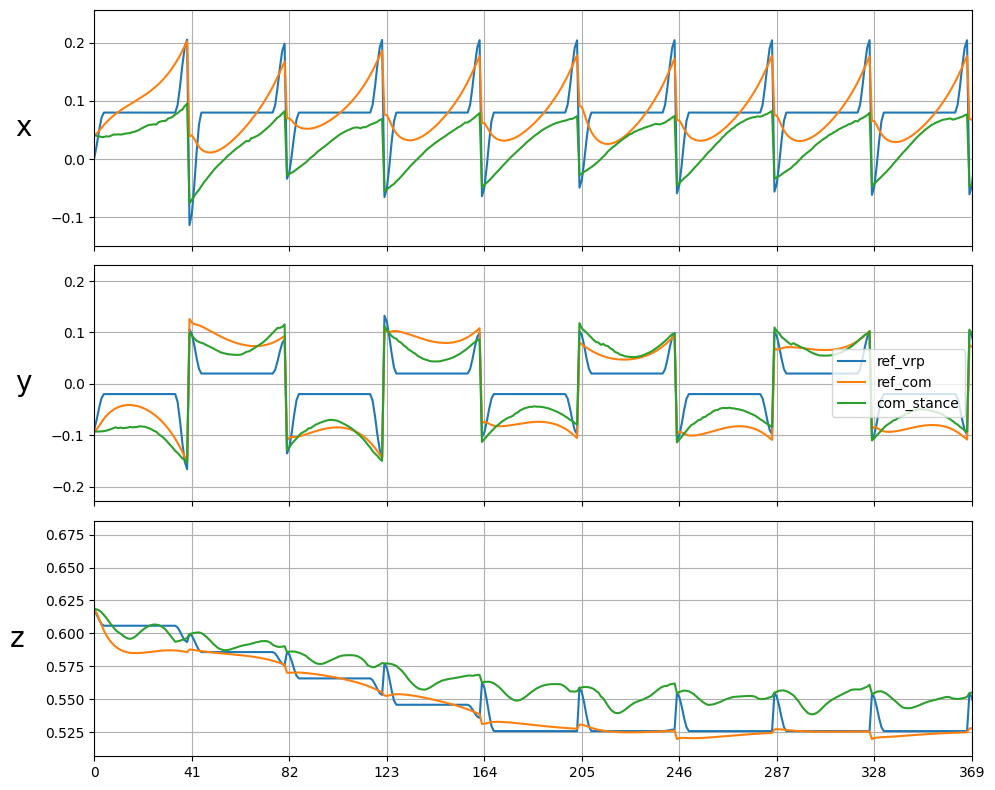

In [55]:
zmp_des = T.filter(regex=r"^ref_zmp").to_numpy()
com_des = T.filter(regex=r"^target_com_stance").to_numpy()
com_cur = T.filter(regex=r"^com_stance").to_numpy()

labels = ["x", "y", "z"]
fig1, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(zmp_des[:, i], label="ref_vrp")
    ax.plot(com_des[:, i], label="ref_com")
    ax.plot(com_cur[:, i], label="com_stance")
    ax.set_ylabel(labels[i], fontsize=20, rotation=0, labelpad=20, va="center")
    ax.set_xlim(0, 300)
    ax.set_xticks(np.arange(0, 400, 41))
    # ax.set_xticklabels(np.arange(1, 6))
    # ax.tick_params(labelbottom=False, labelleft=False)
    ax.grid(True)
    if i == 1:
        ax.legend(loc="right")
# axes[-1].set_xlabel("sample")
# fig1.suptitle("VRP / Preview / Pelvis (stance frame)")
fig1.tight_layout()
plt.show()
